# Question 1: 

ist fachgerechte sondermüll entsorgung in zürich zu teuer, müsste die stadt zürich einen billigen entsorgungsdienst anbieten? korrelieren die anzahl illegal entsorgten abfälle mit dem steuerbaren Einkommen der Bevölkerung


Import libraries

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import datetime as dt
import numpy as np
from scipy import stats

import import_clean_data

### Access and load data via API (züri wie neu, neighbourhoods, income)

In [3]:
zwn_gdf_raw = import_clean_data.import_zwn_data()
neighbourhood_gdf_raw = import_clean_data.import_neighbourhood_data()
population_df_raw = import_clean_data.import_population_data()
income_gdf_raw = import_clean_data.import_income_data()


Data züri wie neu loaded sugessfull
Data züri wie neu loaded sugessfull
Data Population loaded sugessfull
Data Income loaded sugessfull


## clean and filter the data

filter income for the newest year and create a mean for the 3 steuertarife

In [25]:

## filter income for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year (always current year minus 3)
income_df = income_df[income_df["StichtagDatJahr"] == str(current_year -3)].copy()


In [9]:
## create a mean for the 3 steuer tarife

#clean the data (drop na, convert to float)
income_df.dropna(subset=["SteuerEinkommen_p50"])
income_df["SteuerEinkommen_p50"] = income_df["SteuerEinkommen_p50"].astype(float)

#group by neigbourhoods and compute the mean income (of the 3 steuertarife) for each income
steuertarife_grouped_by_neighbourhoods = income_df.groupby("QuarLang", as_index=False)

mean_income_df = steuertarife_grouped_by_neighbourhoods[["SteuerEinkommen_p50"]].mean()
mean_income_df = mean_income_df.rename(columns={"SteuerEinkommen_p50": "mean_income", "QuarLang": "qname"})

filter and clean züri wie neu data

In [10]:
# Sort the züri wie neu data for waste and filter the columns

zwn_waste_gdf = zwn_gdf[zwn_gdf["service_name"]=="Abfall/Sammelstelle"]
zwn_waste_filtered_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]].copy()

clean neighbourhood data

In [11]:
#clean neighbourhoods file

neighbourhoods_filtered_gdf = neighbourhoods_gdf[["qname", "qnr", "geometry"]]

## join and merge data together

In [12]:

#join the trash points to the neighbourhoods

waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_filtered_gdf, 
                                          neighbourhoods_filtered_gdf,
                                          how="inner",
                                          predicate="within")

mask_groupby_neighbourhood = waste_with_neighbourhoods_df.groupby("qname", as_index=False)

neighbourhoods_with_waste_df = waste_with_neighbourhoods_df[["qname"]].value_counts()


In [13]:
# merge the income to the neighbourhoods

neighbourhoods_with_waste_income_df = pd.merge(left=neighbourhoods_with_waste_df, 
                                        right=mean_income_df,
                                        left_on="qname",
                                        right_on="qname")
neighbourhoods_with_waste_income_df = neighbourhoods_with_waste_income_df.sort_values(by="mean_income", ascending=True)
neighbourhoods_with_waste_income_df = neighbourhoods_with_waste_income_df.set_index("qname")





In [17]:

neighbourhoods_with_waste_income_gdf = pd.merge(left=neighbourhoods_filtered_gdf, 
                                        right=neighbourhoods_with_waste_income_df,
                                        left_on="qname",
                                        right_on="qname")

neighbourhoods_with_waste_income_gdf["waste_density"] = neighbourhoods_with_waste_income_gdf["count"]/neighbourhoods_with_waste_income_gdf.geometry.area


## Plot Data


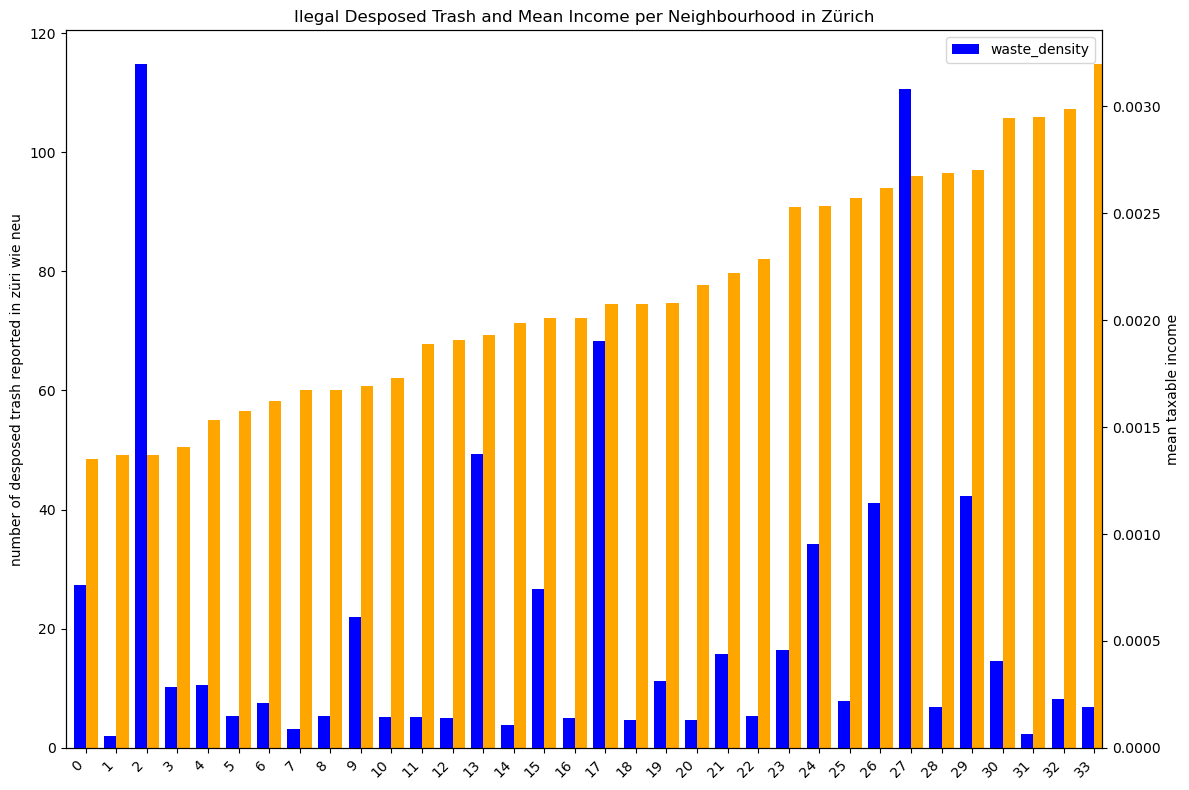

In [18]:
fig, ax1 = plt.subplots(figsize= (12,8))
ax2 = ax1.twinx()

neighbourhoods_with_waste_income_df["mean_income"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               title="Ilegal Desposed Trash and Mean Income per Neighbourhood in Zürich",
                               ylabel="number of desposed trash reported in züri wie neu",
                               xlabel="")
neighbourhoods_with_waste_income_gdf["waste_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="mean taxable income"
                         )
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()
plt.legend()


plt.show()

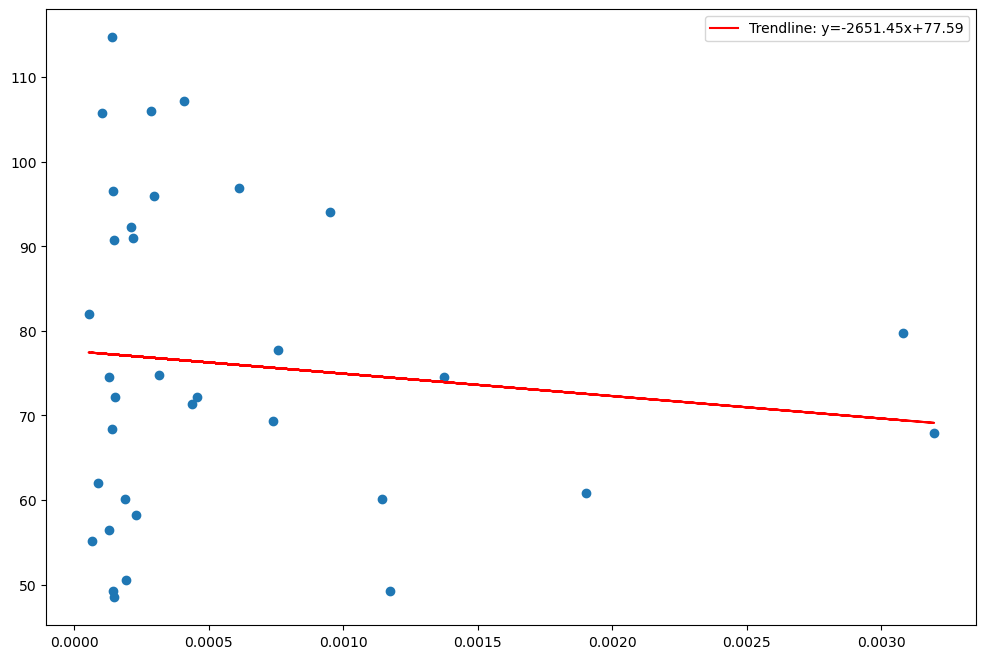

In [19]:
fig, ax3 = plt.subplots(figsize= (12,8))

ax3.scatter(neighbourhoods_with_waste_income_gdf["waste_density"], neighbourhoods_with_waste_income_gdf["mean_income"])
m, b = np.polyfit(neighbourhoods_with_waste_income_gdf["waste_density"], neighbourhoods_with_waste_income_gdf["mean_income"], 1)
x= neighbourhoods_with_waste_income_gdf["waste_density"]
y= neighbourhoods_with_waste_income_gdf["mean_income"]
plt.plot(x, m*x + b, color='red', linestyle='-', label=f'Trendline: y={m:.2f}x+{b:.2f}')
plt.legend()
plt.show()


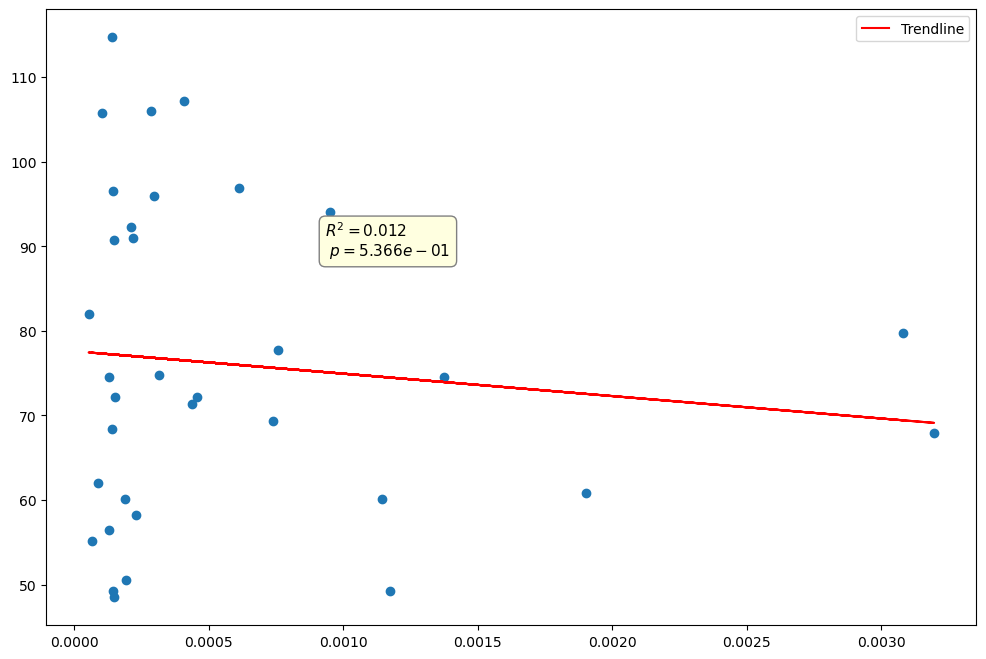

In [23]:
fig, ax3 = plt.subplots(figsize= (12,8))

x= neighbourhoods_with_waste_income_gdf["waste_density"]
y= neighbourhoods_with_waste_income_gdf["mean_income"]

ax3.scatter(x,y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2
y_line = slope * x + intercept
ax3.plot(x, y_line, color='red',label='Trendline')


ax3.annotate(
    f'$R^2 = {r_squared:.3f}$  \n $p = {p_value:.3e}$',
    xy=(0.3, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
    
)


plt.legend()
plt.show()